2D/3D data visualization on mtcars dataset

In [2]:
import pandas as pd
df=pd.read_csv(r"C:\Users\hanal\Desktop\mtcars.csv")
df=df.rename(columns={df.columns[0]:"model"})
df.head()

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


Text(0, 0.5, 'hp')

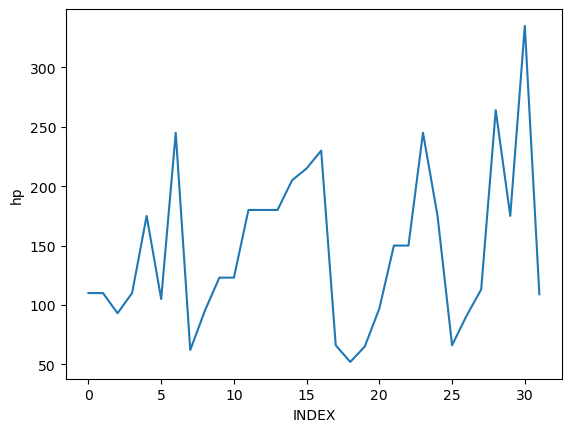

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.plot(df.index,df['hp'])
plt.xlabel('INDEX')
plt.ylabel('hp')

Simple Scatter Plots:

<Axes: xlabel='mpg', ylabel='hp'>

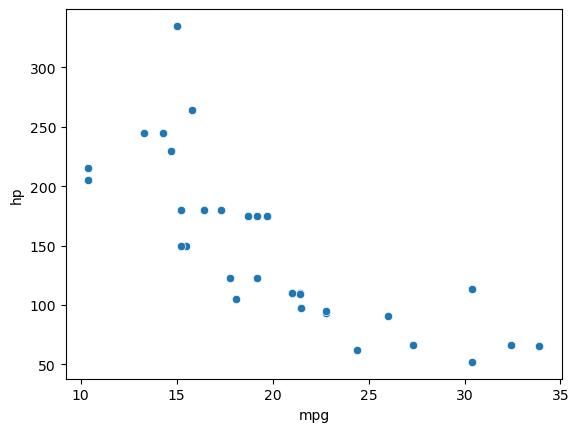

In [4]:
sns.scatterplot(x=df['mpg'],y=df['hp'])

<Axes: xlabel='wt', ylabel='hp'>

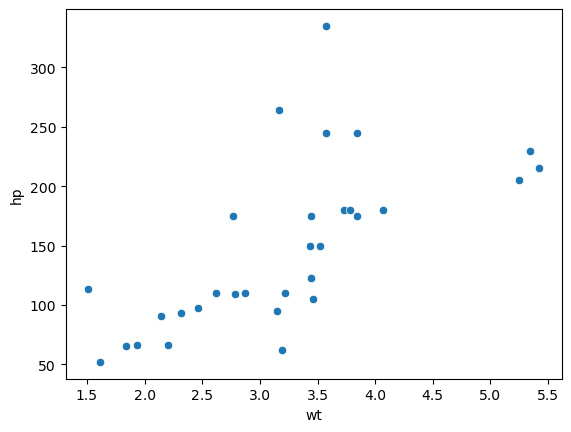

In [5]:
sns.scatterplot(x=df['wt'],y=df['hp'])

Visualizing Errors

Text(0.5, 0, 'hp')

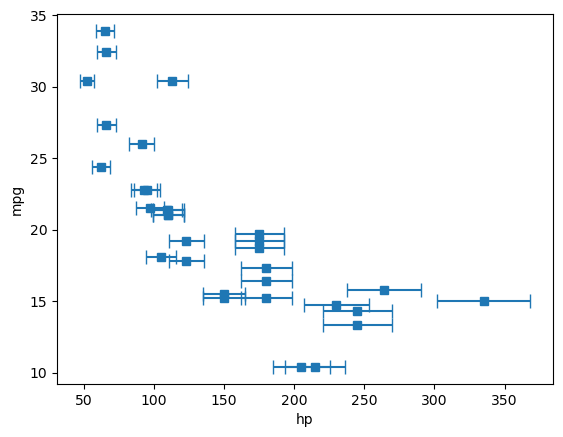

In [20]:
error=0.1*df['hp']
import matplotlib.pyplot as plt

plt.errorbar(df['hp'],df['mpg'],xerr=error,fmt='s',capsize=5)
plt.ylabel('mpg')
plt.xlabel('hp')


Density and Contour Plots: 

Text(0.5, 1.0, 'Contour plot for fuel efficiency')

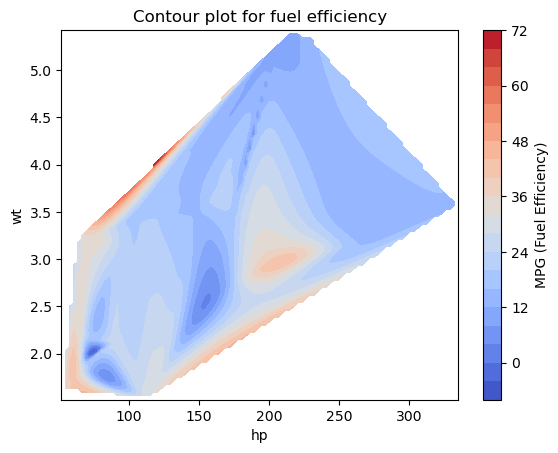

In [28]:
from scipy.interpolate import griddata
import numpy as np
h,w=np.meshgrid(np.linspace(df['hp'].min(),df['hp'].max(),100),np.linspace(df['wt'].min(),df['wt'].max(),100))
m=griddata((df['hp'],df['wt']),df['mpg'],(h,w),method='cubic')
c=plt.contourf(h,w,m,cmap='coolwarm',levels=20)
plt.colorbar(c,label='MPG (Fuel Efficiency)')
plt.xlabel('hp')
plt.ylabel('wt')
plt.title('Contour plot for fuel efficiency')

Data Distribution Visualization

(array([2., 1., 3., 5., 3., 4., 2., 5., 1., 1., 1., 0., 2., 0., 2.]),
 array([10.4       , 11.96666667, 13.53333333, 15.1       , 16.66666667,
        18.23333333, 19.8       , 21.36666667, 22.93333333, 24.5       ,
        26.06666667, 27.63333333, 29.2       , 30.76666667, 32.33333333,
        33.9       ]),
 <BarContainer object of 15 artists>)

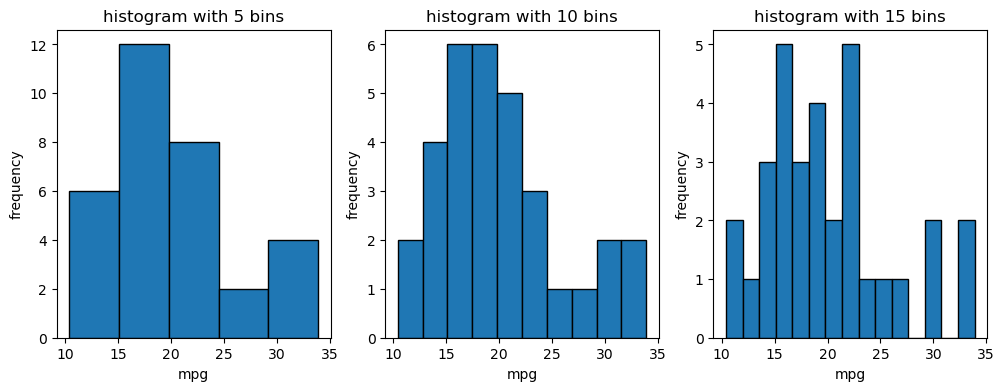

In [36]:
plt.figure(figsize=(12,4))
plt.subplot(131)
plt.title('histogram with 5 bins')
plt.xlabel('mpg')
plt.ylabel('frequency')
plt.hist(df['mpg'],bins=5,edgecolor='black')

plt.subplot(132)
plt.title('histogram with 10 bins')
plt.xlabel('mpg')
plt.ylabel('frequency')
plt.hist(df['mpg'],bins=10,edgecolor='black')

plt.subplot(133)
plt.title('histogram with 15 bins')
plt.xlabel('mpg')
plt.ylabel('frequency')
plt.hist(df['mpg'],bins=15,edgecolor='black')

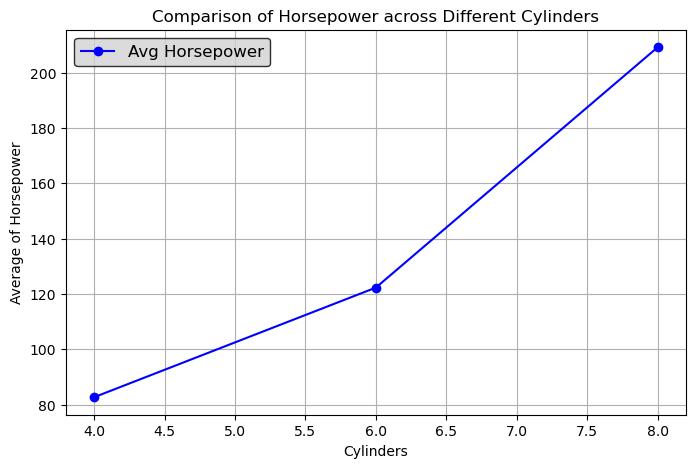

In [42]:
import matplotlib.pyplot as plt

# Group the dataset by cylinders and calculate mean HP
hp_avg = df.groupby('cyl')['hp'].mean()


plt.figure(figsize=(8, 5))
plt.plot(hp_avg.index, hp_avg.values, marker='o', linestyle='-', color='b', label='Avg HP')

plt.legend(['Avg Horsepower'], loc='upper left', fontsize=12, facecolor='lightgray', edgecolor='black')


plt.xlabel('Cylinders')
plt.ylabel('Average of Horsepower')
plt.title('Comparison of Horsepower across Different Cylinders')

plt.grid(True)
plt.show()


Advanced Data visualization 


In [147]:
df=pd.read_csv(r"C:\Users\hanal\Desktop\Video_Games_Sales_as_at_22_Dec_2016.csv")
df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
g = df.groupby('Genre')['Global_Sales'].sum()
y = df.groupby('Year_of_Release')['Global_Sales'].sum()
   


Genre
Action          1745.27
Adventure        237.69
Fighting         447.48
Misc             803.18
Platform         828.08
Puzzle           243.02
Racing           728.90
Role-Playing     934.40
Shooter         1052.94
Simulation       390.42
Sports          1332.00
Strategy         174.50
Name: Global_Sales, dtype: float64

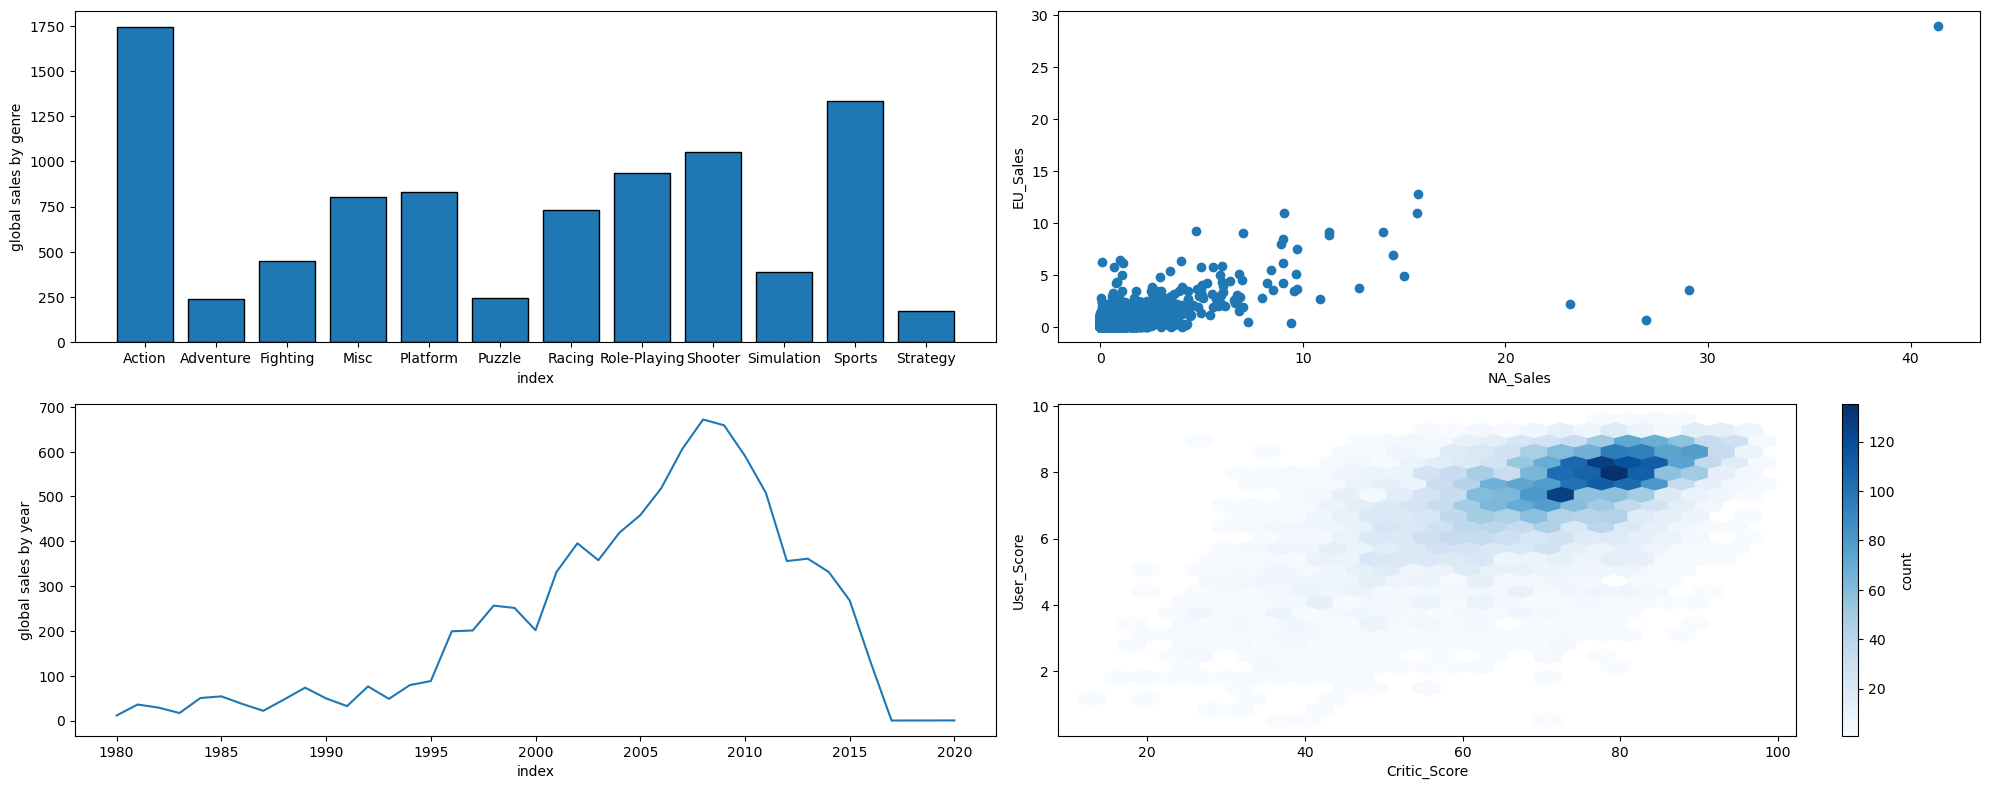

In [60]:
df['Critic_Score'] = pd.to_numeric(df['Critic_Score'], errors='coerce')
df['User_Score'] = pd.to_numeric(df['User_Score'], errors='coerce')

# Drop rows with missing values in these columns
df_clean = df.dropna(subset=['Critic_Score', 'User_Score'])

fig,axes=plt.subplots(2,2,figsize=(20,8))
axes[0,0].bar(g.index,g.values,edgecolor='black')
axes[0,0].set_ylabel('global sales by genre')
axes[0,0].set_xlabel('index')

axes[0,1].scatter(df['NA_Sales'],df['EU_Sales'] )
axes[0,1].set_ylabel('EU_Sales')
axes[0,1].set_xlabel('NA_Sales')

axes[1,0].plot(y.index,y.values)
axes[1,0].set_xlabel('index')
axes[1,0].set_ylabel('global sales by year')


hb = axes[1,1].hexbin(df_clean['Critic_Score'], df_clean['User_Score'], gridsize=25, cmap='Blues', mincnt=1)
fig.colorbar(hb,label='count')
axes[1,1].set_xlabel('Critic_Score')
axes[1,1].set_ylabel('User_Score')

plt.tight_layout()
plt.show()

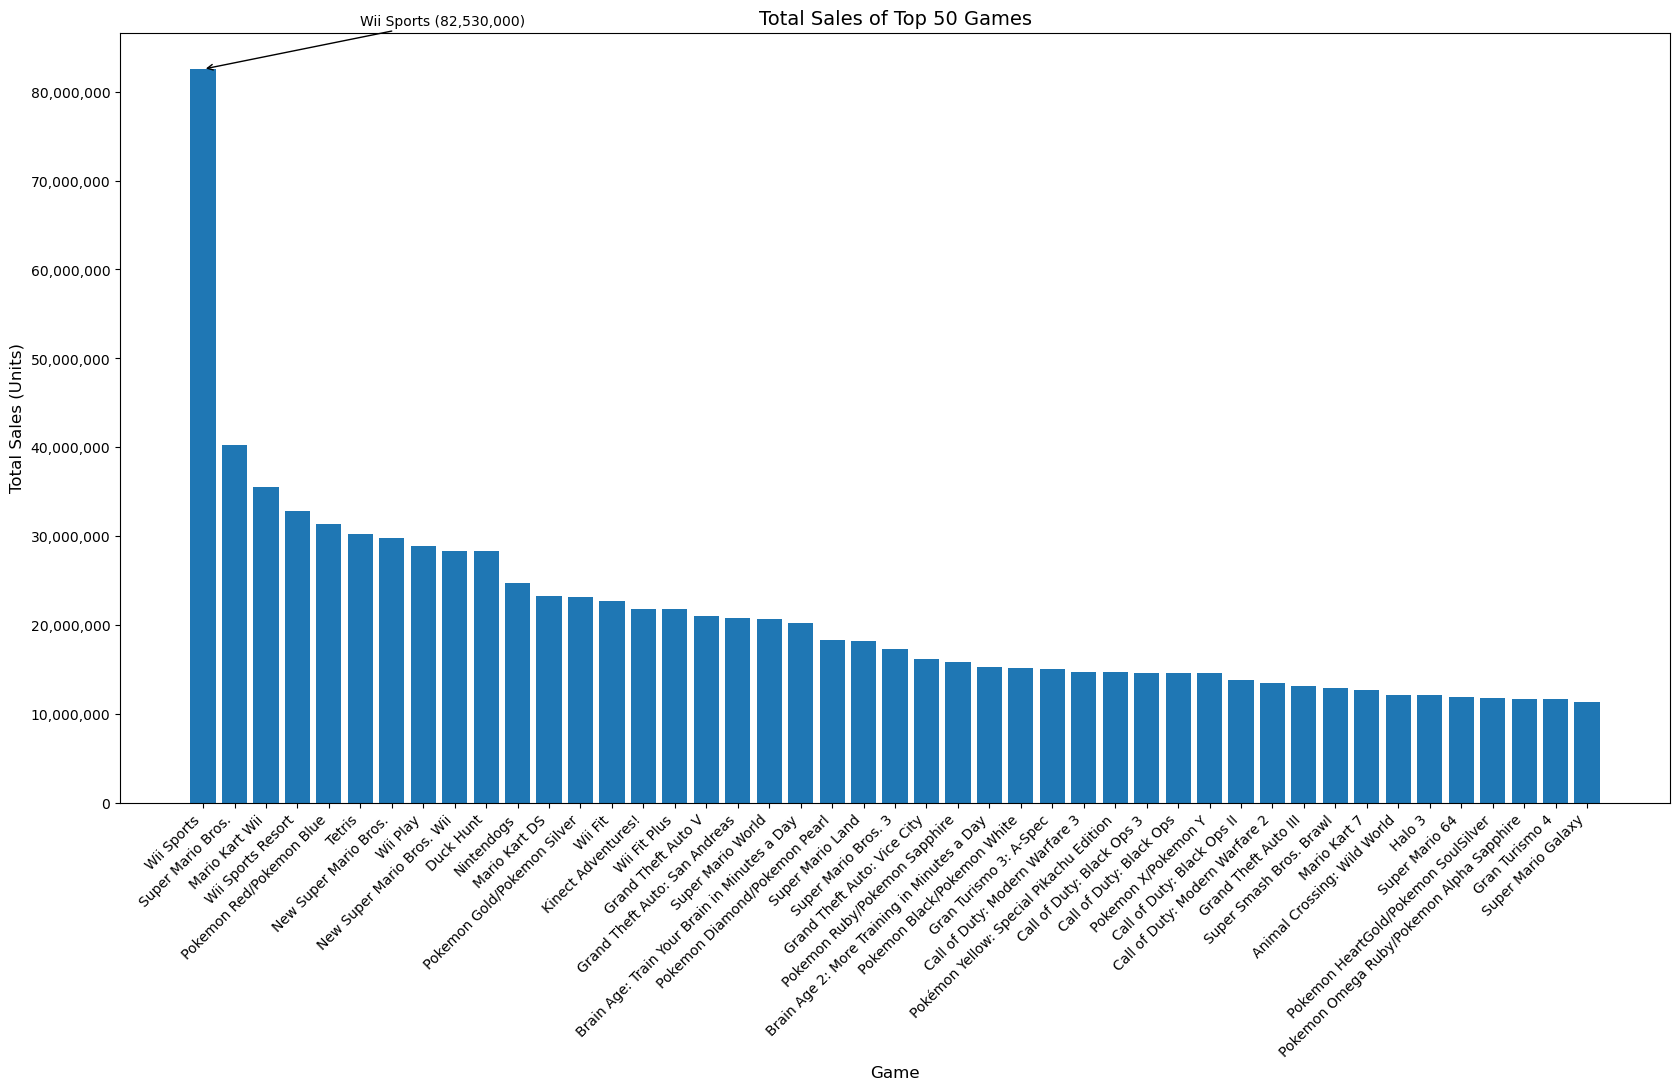

In [92]:

from matplotlib.ticker import FuncFormatter

def l(x, pos):
    return f"{int(x):,}"  

df['Name'] = df['Name'].astype(str)
df_sorted = df.sort_values(by="Global_Sales", ascending=False).head(50)
df_sorted["Global_Sales"] = (df_sorted["Global_Sales"] * 1_000_000).astype(int)
top_game = df_sorted.iloc[0]
plt.figure(figsize=(20, 10))
plt.bar(df_sorted["Name"], df_sorted["Global_Sales"])
plt.annotate(f"{top_game['Name']} ({top_game['Global_Sales']:,})",
             xy=(0, top_game["Global_Sales"]),
             xytext=(5, top_game["Global_Sales"] + 5_000_000), 
             arrowprops=dict(facecolor='red', arrowstyle='->'),
             fontsize=10)

plt.gca().yaxis.set_major_formatter(FuncFormatter(l))

plt.xlabel('Game', fontsize=12)
plt.ylabel('Total Sales (Units)', fontsize=12)
plt.title('Total Sales of Top 50 Games', fontsize=14)
plt.xticks(rotation=45,ha='right', fontsize=10) 
plt.show()


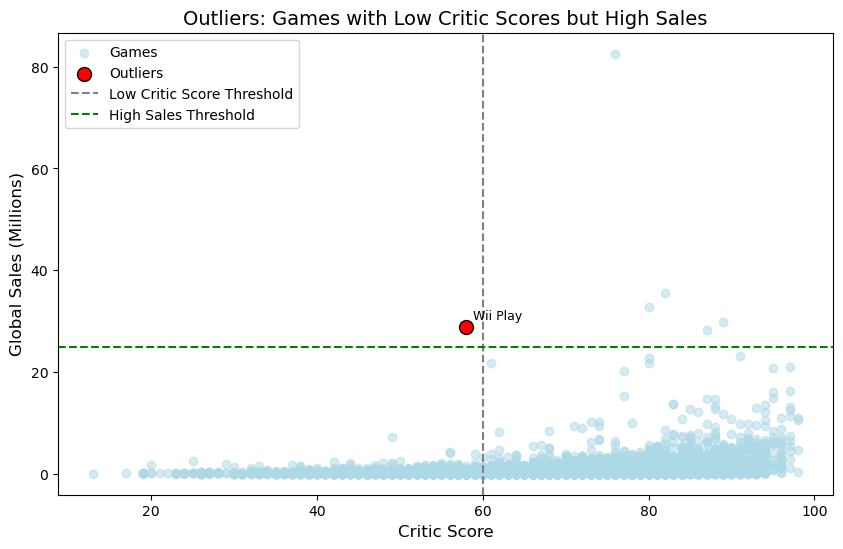

In [74]:
import pandas as pd
import matplotlib.pyplot as plt


low_critic_threshold = 60 
high_sales_threshold = 25 

df['Name'] = df['Name'].astype(str)

outliers = df[(df['Critic_Score'] < low_critic_threshold) & (df['Global_Sales'] > high_sales_threshold)]

plt.figure(figsize=(10, 6))
plt.scatter(df["Critic_Score"], df["Global_Sales"], color="lightblue", alpha=0.5, label="Games")
plt.scatter(outliers["Critic_Score"], outliers["Global_Sales"], color="red", label="Outliers", edgecolors="black", s=100)

for index, row in outliers.iterrows():
    plt.annotate(row["Name"], (row["Critic_Score"], row["Global_Sales"]), fontsize=9, xytext=(5,5), textcoords="offset points")

plt.xlabel("Critic Score", fontsize=12)
plt.ylabel("Global Sales (Millions)", fontsize=12)
plt.title("Outliers: Games with Low Critic Scores but High Sales", fontsize=14)
plt.axvline(low_critic_threshold, color="gray", linestyle="--", label="Low Critic Score Threshold")
plt.axhline(high_sales_threshold, color="green", linestyle="--", label="High Sales Threshold")
plt.legend()
plt.show()


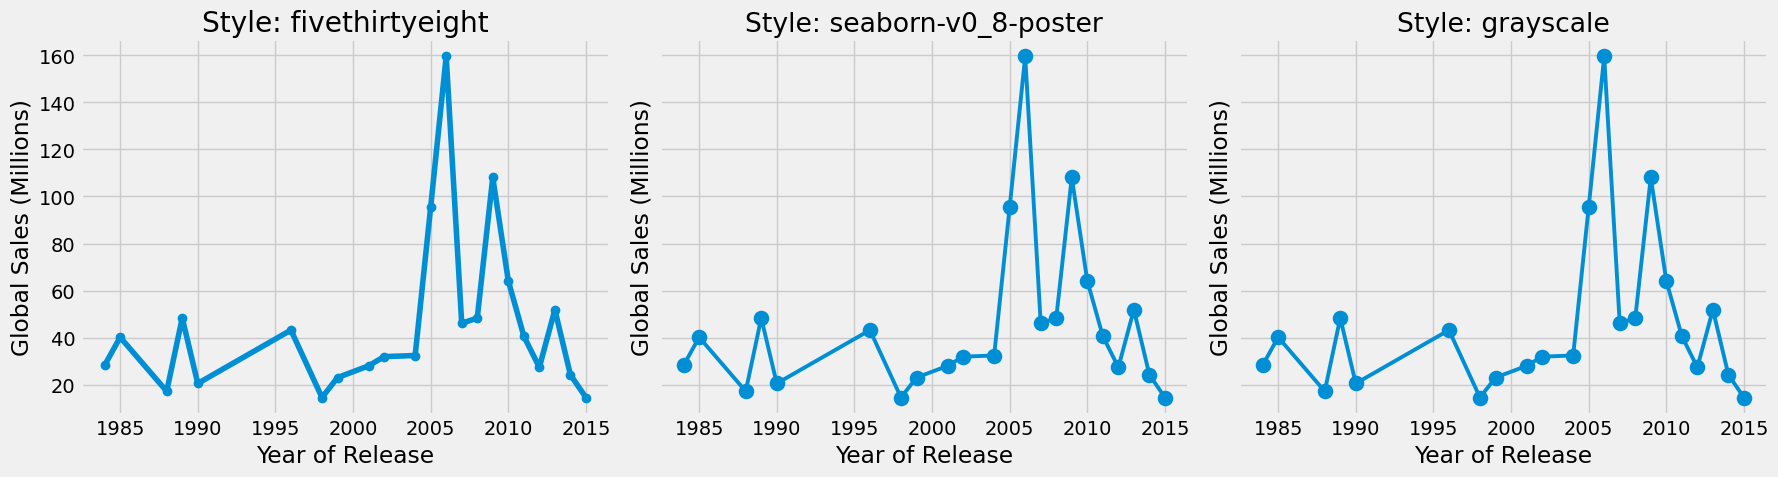

In [96]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure 'Year_of_Release' is numeric
df['Year_of_Release'] = pd.to_numeric(df['Year_of_Release'], errors='coerce')
df_sorted = df.sort_values(by="Global_Sales", ascending=False).head(50)

# Aggregate sales by year
sales_by_year = df_sorted.groupby("Year_of_Release")["Global_Sales"].sum()

# Define valid styles
styles = ["fivethirtyeight", "seaborn-v0_8-poster", "grayscale"]

# Create subplots for comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, style in zip(axes, styles):
    plt.style.use(style)
    ax.plot(sales_by_year.index, sales_by_year.values, marker='o', linestyle='-')
    ax.set_title(f"Style: {style}")
    ax.set_xlabel("Year of Release")
    ax.set_ylabel("Global Sales (Millions)")

plt.tight_layout()
plt.show()



Advanced Visualization Techniques

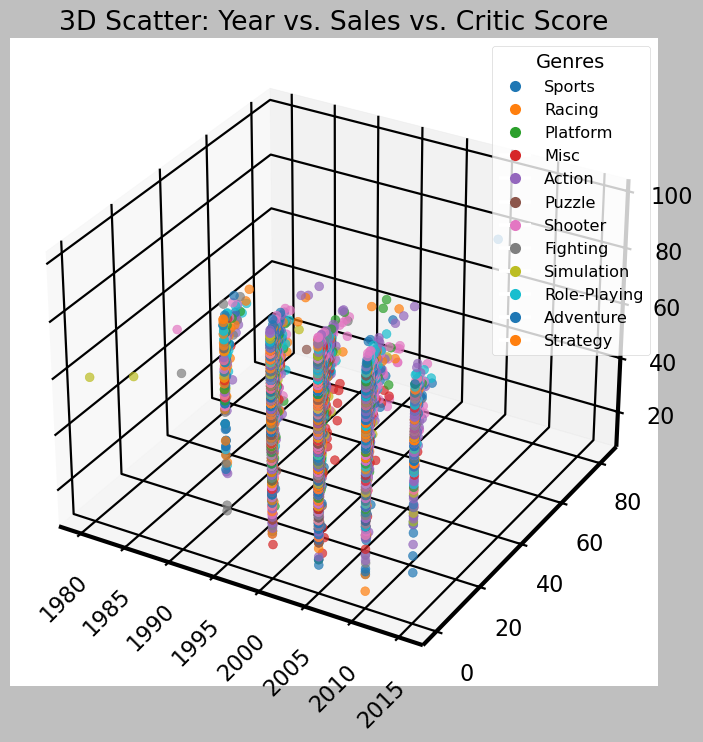

In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

df['Year_of_Release'] = pd.to_numeric(df['Year_of_Release'], errors='coerce')
df = df.dropna(subset=['Year_of_Release', 'Global_Sales', 'Critic_Score', 'Genre'])

df['Year_Binned'] = (df['Year_of_Release'] // 5) * 5  

genres = df['Genre'].unique()
color_map = dict(zip(genres, sns.color_palette("tab10", len(genres))))
df['Color'] = df['Genre'].map(color_map)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df['Year_Binned'], df['Global_Sales'], df['Critic_Score'],
                     c=df['Color'], s=40, alpha=0.7)

ax.set_title("3D Scatter: Year vs. Sales vs. Critic Score")
years = np.arange(int(df['Year_Binned'].min()), int(df['Year_Binned'].max()) + 5, 5)
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)
handles = [plt.Line2D([0], [0], marker='o', color='w', markersize=8,
                      markerfacecolor=color_map[g]) for g in genres]
ax.legend(handles, genres, title="Genres", loc="upper right",fontsize='small')
plt.show()


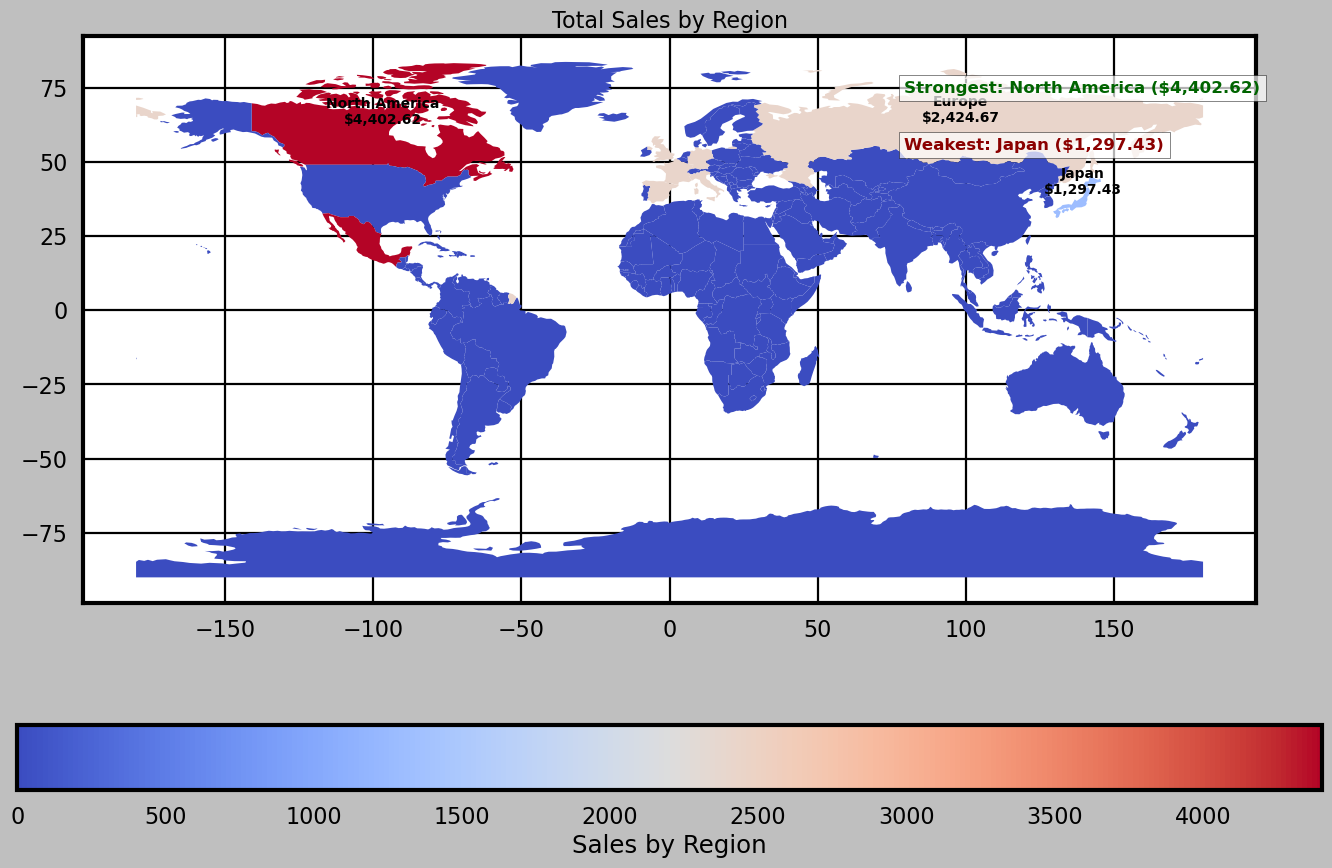

In [166]:

import geopandas as gpd
region_sales = {
    'North America': df['NA_Sales'].sum(),
    'Europe': df['EU_Sales'].sum(),
    'Japan': df['JP_Sales'].sum(),
}

region_sales_df = pd.DataFrame(list(region_sales.items()), columns=['Region', 'Sales'])
world = gpd.read_file(r"C:\Users\hanal\Desktop\ne_110m_admin_0_countries.shp")

region_mapping = {
    'United States': 'North America',
    'Canada': 'North America',
    'Mexico': 'North America',
    'United Kingdom': 'Europe',
    'Germany': 'Europe',
    'France': 'Europe',
    'Italy': 'Europe',
    'Spain': 'Europe',
    'Russia': 'Europe',
    'Japan': 'Japan' 
}

world['Region'] = world['ADMIN'].map(region_mapping).fillna('Other')

world['Sales'] = world['Region'].map(region_sales).fillna(0)

fig, ax = plt.subplots(figsize=(15, 10))
world.plot(column='Sales', ax=ax, legend=True, cmap='coolwarm',
           legend_kwds={'label': "Sales by Region", 'orientation': "horizontal"})

annotated_regions = set()
for idx, row in world.iterrows():
    region = row['Region']
    if row['Sales'] > 0 and region not in annotated_regions:
        xy = row['geometry'].centroid.coords[0]
        ax.annotate(f"{region}\n${row['Sales']:,.2f}",
                    xy=xy, xytext=(3, 3), textcoords="offset points",
                    ha='center', fontsize=10, color='black', weight='bold')
        annotated_regions.add(region) 

strongest = region_sales_df.loc[region_sales_df['Sales'].idxmax()]
weakest = region_sales_df.loc[region_sales_df['Sales'].idxmin()]

ax.annotate(f"Strongest: {strongest['Region']} (${strongest['Sales']:,.2f})",
            xy=(0.7, 0.9), xycoords="axes fraction", fontsize=12,
            color="darkgreen", weight="bold", bbox=dict(facecolor='white', alpha=0.7))

ax.annotate(f"Weakest: {weakest['Region']} (${weakest['Sales']:,.2f})",
            xy=(0.7, 0.8), xycoords="axes fraction", fontsize=12,
            color="darkred", weight="bold", bbox=dict(facecolor='white', alpha=0.7))

plt.title('Total Sales by Region', fontsize=16)
plt.show()
